**Molecular physical pharmacy, 3FC003**

**Molecular dynamics exercise**

# High-throughput peptide self-assembly


#Introduction

This tutorial introduces combinatorial screening for peptide self-assembly using the Martini force field for proteins.

The process is automated using a number of bash scripts, GROMACS tools, and scripting capabilities within the visual molecular dynamics (VMD) program.
After completing the simulations, you will visually inspect the results in py3Dmol and analyze the assembled structures using GROMACS tools.

The material is organized in a folder directory tree that is numbered by the folowing

subsections:

 - 1_Background
  
 - 2_Creating_coordinates
  
 - 3_Coarse-graining

 - 4_Running_simulations

 - 5_Analysis

Each folder contains the files required for the tutorial. The outputs from a successful execution of the tutorial are also provided. This allows you to review your work and also begin at any point should you encounter an issue.

For example, if you want to jump in at step 4, you can enter the directory 3_Done and continue there in the directory 4_Running_simulations.

The main idea of this tutorial is to show you and help you practice the commands needed to complete the different steps for a single peptide. However, in the files provided, you will also find several scripts that can help you perform the operations automatically and set up a high-throughput assay.

Finally, this exercise is based on a tutorial available on the [Martini force field](https://cgmartini.nl/docs/tutorials/) , which is gratefully acknowledged.

## 1. Background

Molecular self-assembly of oligopeptides into nanostructures holds much promise for a range of potential applications in biomedicine, food science, cosmetics and nanotechnology. This class of materials is highly versatile because of the combinatorial complexity achieved by combining 20 amino acids into peptide building blocks with a wide range of chemical functionality. The use of very short peptides is especially attractive, enhancing opportunities for rational design combined with robustness, scalability and cost reduction.

Two main challenges are currently limiting the expansion of this field:

- Most examples of short peptides contain only hydrophobic amino acids. This is no surprise as hydrophobic interactions dominate self-assembly in water, but it also limits their aqueous solubility and restricts potential applications.

- Secondly, in spite of two decades of intensive research since the first examples of short self-assembling peptides, most examples have been either discovered by serendipity or by mapping onto known sequence design rules from biological systems.

Using the [Martini](https://cgmartini.nl/) force field, the self-assembly of thousands of peptides can be tested *in silico*, before spending time and resources in the lab. Experimental validation has shown that Martini not only accurately represents the level of aggregation between peptides, but also informs on the supramolecular structure of the nanosized assemblies ([Sasselli et al.](https://doi.org/10.1021/acs.jctc.3c01015)).

In the field of peptide nanomaterials, it is common practice to ‘protect’ the N- and/or C-terminus of a peptide to introduce specific interactions and remove charge-charge repulsions.

Examples include acetyl, Fmoc, naphthalene, pyrene, and t-Boc functional groups at the N-terminus, or amide and ester groups at the C-terminus.

In this tutorial, you will apply a combinatorial screening protocol to tripeptides, specifically those discovered by [Ray et al](https://doi.org/10.1016/j.tet.2006.05.042).

Ray et al. found that placing tyrosine residues at both the N- and the C-terminus of a tripeptide drives the system to crystallize into hollow nanotubes with a 5 Å inner diameter (Figure 1).

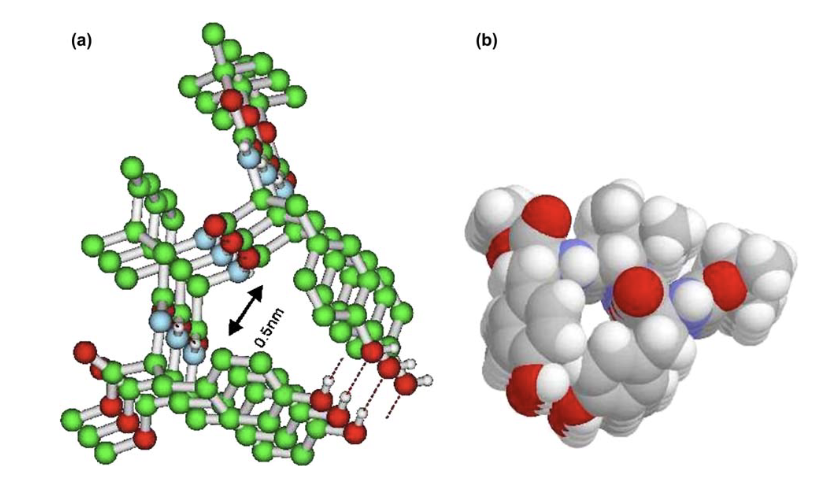

Figure 1.
- (a) Top view of the development of intermolecularly hydrogen-bonded nanotubular structure along the crystallographic b axis exhibiting internal tubular diameter of about 5.0 A in ball and stick model.The tubular structure is composed of the acyclic peptide 2 subunit with extended backbone conformation (which adopts a b-strand like structure).
- (b) Space-ﬁlling model of the nanotubular ensemble obtained from a higher order self-assembly of the peptide 2.

Ray et al. showed that Boc–Tyr–X–Tyr–OMe peptides, where X is Val or Ile, assemble into nanotubular structures in the crystalline state[[1]](https://doi.org/10.1021/ol048253a). Subsequent crystallographic studies indicated that replacing either terminal tyrosine disrupts the molecular organization required for nanotube formation[[2]](https://doi.org/10.1016/j.tet.2006.05.042).

**These findings raise the question of whether peptides containing other central residues preserve the nanotubular architecture or adopt alternative morphologies.**

Moreover, because the reported structures were obtained by crystallization from aqueous methanol, their formation and stability under fully aqueous conditions remain to be established.

The folder **1_Background** contains some references and further reading for those that are interested, but reading this is optional.

# 1.1 Setting up the virtual computing environment

- a) Click on the menu **Runtime** / **Change runtime type**.
- b) Select the **CPU** option as Hardware accelerator, and **save**.
- c) Click on the **Connect** button on the right (It is located below the **Share** button).


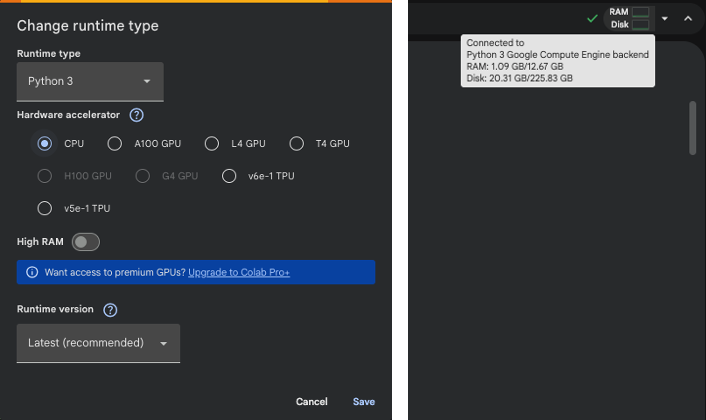

- d) Click the **Folder icon** on the left. This will display your virtual disk and the files you will create throughout this tutorial. Initially, you will see only a sample_data folder.
- e) After cloning the course repository, the **3FC003** folder and its directory tree will be visible. Click the 3FC003 folder to explore its contents.

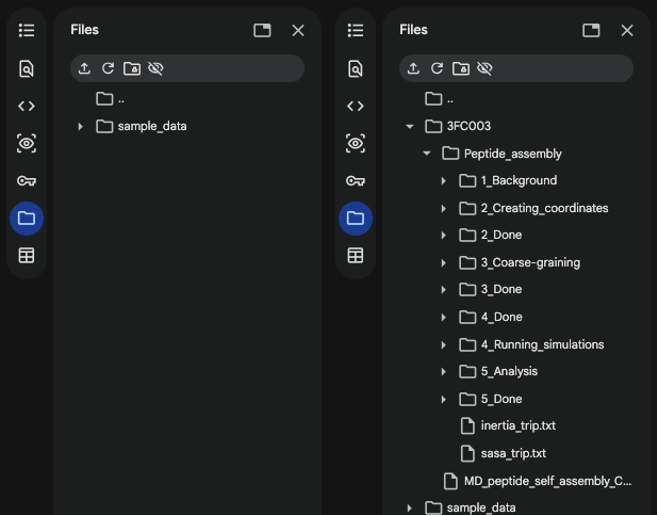

In [1]:
# 1.2 Cloning the course repository
!git clone https://github.com/computationalpharmaceutics/3FC003.git

Cloning into '3FC003'...
remote: Enumerating objects: 650, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 650 (delta 27), reused 29 (delta 13), pack-reused 605 (from 1)
Receiving objects: 100% (650/650), 168.34 MiB | 23.38 MiB/s, done.
Resolving deltas: 100% (302/302), done.


In [2]:
# 1.3 Installing py3Dmol
%pip install -q py3Dmol ipywidgets openmm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 75.1 MB/s eta 0:00:00


In [3]:
# 1.4 Installing VMD 1.9.3
%%bash

mkdir -p /content/micromamba

curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest \
  | tar -xj -C /content/micromamba bin/micromamba

/content/micromamba/bin/micromamba create \
  -y -q \
  -p /content/vmd \
  -c conda-forge \
  vmd=1.9.3

/content/vmd/bin/vmd -dispdev text -eofexit < /dev/null

Info) VMD for LINUXAMD64, version 1.9.3 (November 30, 2016)
Info) http://www.ks.uiuc.edu/Research/vmd/                         
Info) Email questions and bug reports to vmd@ks.uiuc.edu           
Info) Please include this reference in published work using VMD:   
Info)    Humphrey, W., Dalke, A. and Schulten, K., `VMD - Visual   
Info)    Molecular Dynamics', J. Molec. Graphics 1996, 14.1, 33-38.
Info) -------------------------------------------------------------
Info) Multithreading available, 2 CPUs detected.
Info)   CPU features: SSE2 AVX AVX2 FMA 
Info) Free system memory: 12GB (90%)
Info) No CUDA accelerator devices available.
Info) Dynamically loaded 2 plugins in directory:
Info) /content/vmd/lib/vmd/plugins/LINUXAMD64/molfile
Info) VMD for LINUXAMD64, version 1.9.3 (November 30, 2016)
Info) Exiting normally.


/content/vmd/lib/vmd/vmd_LINUXAMD64: /lib/x86_64-linux-gnu/libGL.so.1: no version information available (required by /content/vmd/lib/vmd/vmd_LINUXAMD64)


In [4]:
# 1.5 Installing GROMACS 2023.3 with CPU support only
!apt install gromacs &> /dev/null
!gmx -version

              :-) GROMACS - gmx, 2023.3-Ubuntu_2023.3_1ubuntu3 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /content
Command line:
  gmx -version

GROMACS version:    2023.3-Ubuntu_2023.3_1ubuntu3
Precision:          mixed
Memory model:       64 bit
MPI library:        thread_mpi
OpenMP support:     enabled (GMX_OPENMP_MAX_THREADS = 128)
GPU support:        disabled
SIMD instructions:  SSE4.1
CPU FFT library:    fftw-3.3.10-sse2-avx
GPU FFT library:    none
Multi-GPU FFT:      none
RDTSCP usage:       enabled
TNG support:        enabled
Hwloc support:      hwloc-2.8.0
Tracing support:    disabled
C compiler:         /usr/bin/cc GNU 13.2.0
C compiler flags:   -fexcess-precision=fast -funroll-all-loops -msse4.1 -Wno-missing-field-initializers -O3 -DNDEBUG
C++ compiler:       /usr/bin/c++ GNU 13.2.0
C++ compiler flags: -fexcess-precision=fast -funroll-all-loops -msse4.1 -Wno-missing-field-initializers -Wno-cast-function-type-strict SHELL:-fopenmp -O3 -DNDEBUG
BLAS libr

In [5]:
# 1.6 Installing Python 2.7 to run Martini 2 (martinize.py)
from pathlib import Path
PY2_ENV = Path("/content/martinize-python2")
PY2 = PY2_ENV / "bin/python"

if not PY2.is_file():
    print("Creating a Python 2.7 environment to run Martini (martinize.py)")
    !/content/micromamba/bin/micromamba create \
        -y -q \
        -p {PY2_ENV} \
        -c conda-forge/label/cf202003 \
        python=2.7

assert PY2.is_file(), "Micromamba did not create a Python 2.7 interpreter."
print(f"Python 2.7 is ready: {PY2}")
!{PY2} --version

Creating a Python 2.7 environment to run Martini (martinize.py)
Python 2.7 is ready: /content/martinize-python2/bin/python
Python 2.7.15


In [32]:
# 1.7 Importing necessary modules

import os
import sys
import importlib
import shutil
import re
import subprocess
import matplotlib.pyplot as plt

# Loading peptide visualization self-defined functions
MODULE_DIR = "/content/3FC003"
sys.path.insert(0, MODULE_DIR)
import MD_peptide_self_assembly as peptide_tools


## 2. Creating the 20 Tyr–X–Tyr coordinates

To simplify the tripeptides for this exercise, we will treat Boc-Tyr-X-Tyr-OMe as a simple Tyr-X-Tyr peptide with uncharged termini, so that all parameters for coarse-graining are available within the Martini force field for proteins. We want to test all 20 mutations of the middle amino acid (X). An easy way to create the 20 different peptide coordinates is using a molecular builder such as Avogadro, VMD or Pymol.

The files discussed here can be found in the directory `2_Creating_coordinates`.

Go into the directory `2_Creating_coordinates` to create 20 all-atom structures.

Replace `directory_name` with  `2_Creating_coordinates`  inside the brackets below and run the cell to navigate to the directory where the peptides will be generated.

In [7]:
# 2.1 Replace directory_name with 2_Creating_coordinates

COORD_DIR = Path("/content/3FC003/Peptide_assembly/2_Creating_coordinates")


In [8]:
# 2.2. Go to the folder that contains make_peptides.sh.
%cd $COORD_DIR

# Make the shell script executable (this is required only once).
!chmod +x make_peptides.sh

/content/3FC003/Peptide_assembly/2_Creating_coordinates


To generate the 20 peptides, write: `!./make_peptides.sh`, and execute the cell below.

In [9]:
# 2.3. To generate the 20 peptides:
!./make_peptides.sh

TYR
/content/vmd/lib/vmd/vmd_LINUXAMD64: /lib/x86_64-linux-gnu/libGL.so.1: no version information available (required by /content/vmd/lib/vmd/vmd_LINUXAMD64)
Info) VMD for LINUXAMD64, version 1.9.3 (November 30, 2016)
Info) http://www.ks.uiuc.edu/Research/vmd/                         
Info) Email questions and bug reports to vmd@ks.uiuc.edu           
Info) Please include this reference in published work using VMD:   
Info)    Humphrey, W., Dalke, A. and Schulten, K., `VMD - Visual   
Info)    Molecular Dynamics', J. Molec. Graphics 1996, 14.1, 33-38.
Info) -------------------------------------------------------------
Info) Multithreading available, 2 CPUs detected.
Info)   CPU features: SSE2 AVX AVX2 FMA 
Info) Free system memory: 11GB (89%)
Info) No CUDA accelerator devices available.
Info) Dynamically loaded 2 plugins in directory:
Info) /content/vmd/lib/vmd/plugins/LINUXAMD64/molfile
1.6.4
psfgen) reading topology file top_all36_prot.rtf

psfgen) >>>>>>>>CHARMM36 All-Hydrogen Topol

In [10]:
# 2.4 Optimizing the three-dimensional structures of the twenty generated tripeptides.
generated = peptide_tools.minimize_peptides(COORD_DIR)
print(f"Minimized {len(generated)} peptides in {COORD_DIR}")

TYR-ALA-TYR_aa.pdb: 315.7 kJ/mol -> -430.9 kJ/mol
TYR-ARG-TYR_aa.pdb: -762.6 kJ/mol -> -1526.3 kJ/mol
TYR-ASN-TYR_aa.pdb: 96.1 kJ/mol -> -728.1 kJ/mol
TYR-ASP-TYR_aa.pdb: -93.0 kJ/mol -> -884.7 kJ/mol
TYR-CYS-TYR_aa.pdb: 364.6 kJ/mol -> -404.4 kJ/mol
TYR-GLN-TYR_aa.pdb: 142.4 kJ/mol -> -631.0 kJ/mol
TYR-GLU-TYR_aa.pdb: -45.3 kJ/mol -> -808.4 kJ/mol
TYR-GLY-TYR_aa.pdb: 308.9 kJ/mol -> -464.8 kJ/mol
TYR-HIS-TYR_aa.pdb: 275.4 kJ/mol -> -496.2 kJ/mol
TYR-ILE-TYR_aa.pdb: 384.3 kJ/mol -> -391.5 kJ/mol
TYR-LEU-TYR_aa.pdb: 437.8 kJ/mol -> -460.5 kJ/mol
TYR-LYS-TYR_aa.pdb: 131.1 kJ/mol -> -633.0 kJ/mol
TYR-MET-TYR_aa.pdb: 361.3 kJ/mol -> -405.6 kJ/mol
TYR-PHE-TYR_aa.pdb: 408.2 kJ/mol -> -364.1 kJ/mol
TYR-PRO-TYR_aa.pdb: 1717.5 kJ/mol -> -289.6 kJ/mol
TYR-SER-TYR_aa.pdb: 367.1 kJ/mol -> -404.6 kJ/mol
TYR-THR-TYR_aa.pdb: 286.7 kJ/mol -> -489.2 kJ/mol
TYR-TRP-TYR_aa.pdb: 469.7 kJ/mol -> -302.0 kJ/mol
TYR-TYR-TYR_aa.pdb: 333.1 kJ/mol -> -438.6 kJ/mol
TYR-VAL-TYR_aa.pdb: 360.0 kJ/mol -> -419.5 kJ/mo

### Explore the optimized peptides

If everything went smoothly, you should now have 20 all-atom structures of tripeptides. You can verify this by selecting a peptide and a style from the dropdown menus below.

In [11]:
# 2.5 Visualize the 3D structure of every tripeptide

peptide_tools.show_peptide_widget(generated, COORD_DIR)

interactive(children=(Dropdown(description='Peptide:', index=19, options=('TYR-ALA-TYR', 'TYR-ARG-TYR', 'TYR-A…

<function MD_peptide_self_assembly.show_peptide(peptide: str, style: str, coord_dir: Union[str, pathlib._local.Path]) -> None>

If all is well, you have now generated 20 all-atom structures of tripeptides.

If you are interested in the details of this procedure, read the text in italics below. However, you may press on and get the simulation running instead. It's up to you!

*The idea of generating coordinates for each peptide is to use a template structure for a tripeptide and use this template to graft TYR-X-TYR unto the side chains. To this end, generic tripeptide coordinates are provided in the file XYZ.pdb. If you inspect this file, you will see coordinates for an atomistic model containing only the backbone atoms. There are several ways to generate such a file. Avogadro was mentioned. PyMOL also includes an amino-acid builder.*

*The script make_peptides.sh loops over all 20 amino acids and edits the template file XYZ.pdb and additionally uses the script create_tripeptides.tcl to reflect the residues to be grafted onto the coordinate template to generate an instruction set for VMD.*

*For each tripeptide, the script make_peptides.sh then calls VMD with this instruction set to generate the coordinates of the required tripeptide. Note that the script make_peptides.sh can easily be modified to generate coordinates for all possible tripeptides.*

If you want to have a better idea of how the peptides were generated, double-click on the file `make_peptides.sh` to inspect it.

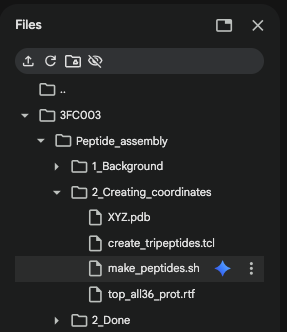

## 3. Create a coarse-grained system using martinize.py and GROMACS tools


In this step, one or more of the atomistic structures generated in step 2 are used to generate a Martini coarse-grained topology file, a coarse-grained structure of a single tripeptide, and a simulation box containing 100 peptides and solvent randomly placed in the box.

The files discussed here can be found in the directory `3_Coarse-graining`.

Coarse-grained Martini topologies of peptides and proteins can be built automatically using the martinize.py script. Execute the `martinize.py` script on a tripeptide of your choice to create coarse-grained coordinates using the Martini 2.2 force field. Remember to use neutral termini! In the papers discussing the YXY peptide it is mentioned that the backbone dihedral angles in the crystal structure fall in the β-sheet Ramachandran region. We therefore use the extended β secondary structure for all three amino acids (flag ‘-ss EEE’). In the commands below, replace X by the three-letter amino acid code of your choice:

In [12]:
# 3.1 Replace "X" with the three-letter code for the middle amino acid.
# You could use : "ALA" "CYS" "ASP" "GLU" "PHE" "GLY" "HIS" "ILE" "LYS" "LEU" "MET" "ASN" "PRO" "GLN" "ARG" "SER" "THR" "VAL" "TRP" "TYR"
MIDDLE_RESIDUE = "ARG"

PEPTIDE = f"TYR-{MIDDLE_RESIDUE}-TYR"

CG_DIR = Path("/content/3FC003/Peptide_assembly/3_Coarse-graining")
COORD_FILE = CG_DIR.parent / "2_Creating_coordinates" / f"{PEPTIDE}_aa.pdb"


print(f"Selected peptide: {PEPTIDE}")

Selected peptide: TYR-ARG-TYR


In [13]:
# 3.2 Run martinize.py on the selected peptide.
#    -nt gives neutral termini; -ss EEE assigns an extended beta structure.
MARTINIZE = CG_DIR / "martinize.py"

assert MARTINIZE.is_file(), f"Script not found: {MARTINIZE}"
assert COORD_FILE.is_file(), f"Coordinate file not found: {COORD_FILE}"

%cd $CG_DIR

!{PY2} ./martinize.py \
    -f {COORD_FILE} \
    -name {PEPTIDE} \
    -o {PEPTIDE}.top \
    -x {PEPTIDE}.pdb \
    -ff martini22 \
    -nt \
    -ss EEE

/content/3FC003/Peptide_assembly/3_Coarse-graining
INFO       MARTINIZE, script version 2.4
INFO       If you use this script please cite:
INFO       de Jong et al., J. Chem. Theory Comput., 2013, DOI:10.1021/ct300646g
INFO       Chain termini will not be charged
INFO       Residues at chain brakes will not be charged
INFO       The martini22 forcefield will be used.
INFO       Local elastic bonds will be used for extended regions.
INFO       Read input structure from file.
INFO       Input structure is a PDB file.
INFO       Found 1 chains:
INFO          1:     (Protein), 69 atoms in 3 residues.
INFO       Total size of the system: 3 residues.
INFO       Secondary structure read from command-line:
EEE
INFO       Writing coarse grained structure.
INFO       (Average) Secondary structure has been determined (see head of .itp-file).
INFO       Created coarsegrained topology
INFO       Written 1 ITP file
INFO       Output contains 1 molecules:
INFO          1->  TYR-ARG-TYR (chain   )
INF

You need to edit the output file `TYR-X-TYR.top`. The martinize.py script adds an #include statement to the generic Martini force field file:

In [14]:
# 3.3 Printing the contents od the topology file "TYR-X-TYR.top"
top_file = CG_DIR / f"{PEPTIDE}.top"
text = top_file.read_text()
print("Topology before:\n")
print(text)

Topology before:

#include "martini.itp"
    

  
#include "TYR-ARG-TYR.itp"
    
[ system ]
; name
Martini system from /content/3FC003/Peptide_assembly/2_Creating_coordinates/TYR-ARG-TYR_aa.pdb
    
[ molecules ]
; name        number
TYR-ARG-TYR 	 1


In [15]:
# 3.4 Adding the Martini version to the topology file "TYR-X-TYR.top"
text = text.replace(
    '#include "martini.itp"',
    '#include "martini_v2.2.itp"',
)
top_file.write_text(text)

print("\nTopology after:\n")
print(top_file.read_text())


Topology after:

#include "martini_v2.2.itp"
    

  
#include "TYR-ARG-TYR.itp"
    
[ system ]
; name
Martini system from /content/3FC003/Peptide_assembly/2_Creating_coordinates/TYR-ARG-TYR_aa.pdb
    
[ molecules ]
; name        number
TYR-ARG-TYR 	 1


### Inspect the bead mapping

Inspect the output file TYR-X-TYR.itp to see what bead types were chosen for different parts of the peptide. Does it make sense?


In [16]:
# 3.5 Printing the content of the "TYR-X-TYR.itp" file

itp_text = (CG_DIR / f'{PEPTIDE}.itp').read_text()

print(itp_text)

; MARTINI (martini22) Coarse Grained topology file for "TYR-ARG-TYR"
; Created by py version 2.4 
; Using the following options:  -f /content/3FC003/Peptide_assembly/2_Creating_coordinates/TYR-ARG-TYR_aa.pdb -name TYR-ARG-TYR -o TYR-ARG-TYR.top -x TYR-ARG-TYR.pdb -ff martini22 -nt -ss EEE
; Sequence:
; YRY
; Secondary Structure:
; EEE

[ moleculetype ]
; Name         Exclusions
TYR-ARG-TYR       1

[ atoms ]
    1   Nda     1   TYR    BB     1  0.0000 ; E
    2   SC4     1   TYR   SC1     2  0.0000 ; E
    3   SC4     1   TYR   SC2     3  0.0000 ; E
    4   SP1     1   TYR   SC3     4  0.0000 ; E
    5   Nda     2   ARG    BB     5  0.0000 ; E
    6    N0     2   ARG   SC1     6  0.0000 ; E
    7    Qd     2   ARG   SC2     7  1.0000 ; E
    8   Nda     3   TYR    BB     8  0.0000 ; E
    9   SC4     3   TYR   SC1     9  0.0000 ; E
   10   SC4     3   TYR   SC2    10  0.0000 ; E
   11   SP1     3   TYR   SC3    11  0.0000 ; E

[ bonds ]
; Backbone bonds
    1     5      1   0.35000  12

### Compare the all-atom and Martini structures

The table summarizes the bead properties read from the generated topology and force-field files. The panels below it show the optimized all-atom peptide on the left and the Martini 2.2 representation on the right. Each sphere is labeled as `bead name | Martini type | class| polarity / H-bonding`; drag either panel to rotate both structures together.


In [17]:
# 3.6 Showing the Martini coarse-grained model of the selected tripeptide
bead_table = peptide_tools.show_peptide_comparison(PEPTIDE, CG_DIR)

residue,bead,Martini type,class,polarity / H-bonding
TYR 1,BB,Nda,intermediate,donor + acceptor
TYR 1,SC1,SC4,apolar,level 4
TYR 1,SC2,SC4,apolar,level 4
TYR 1,SC3,SP1,polar,level 1
ARG 2,BB,Nda,intermediate,donor + acceptor
ARG 2,SC1,N0,intermediate,none
ARG 2,SC2,Qd,charged,donor
TYR 3,BB,Nda,intermediate,donor + acceptor
TYR 3,SC1,SC4,apolar,level 4
TYR 3,SC2,SC4,apolar,level 4


Color key: charged=red, polar=orange, intermediate=blue, apolar=gray.
Connectivity: 1-5, 5-8, 1-2, 5-6, 6-7, 8-9, 2-3, 2-4, 3-4, 9-10, 9-11, 10-11


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Build and solvate the peptide box

When you have the coarse-grained coordinates of a single peptide and created its topology, create a small box of water containing enough peptides to create a self-assembled structure. For this exercise, a small box of 8 x 8 x 8 nm containing 100 peptides can be used.

The Gromacs tools insert-molecules and solvate enable you to first define the box and fill it with 100 peptides and next, fill the box containing the 100 peptides with Martini water.

`gmx insert-molecules` randomly places 100 peptides in the 8 nm cubic box, and `gmx solvate` fills the remaining space with the supplied equilibrated Martini water. The radii reduce initial peptide overlap and give a suitable water density. The peptide concentration is approximately 0.32 M—deliberately high so self-assembly occurs on an accessible simulation timescale.


In [18]:
# 3.7 Insert 100 peptides into an 8 x 8 x 8 nm box.
N_PEPTIDES = 100
box_file = CG_DIR / f'{PEPTIDE}_box.gro'
water_file = CG_DIR / f'{PEPTIDE}_water.gro'
os.environ['GMX_MAXBACKUP'] = '-1'
gmx_env = os.environ.copy()

%cd $CG_DIR
! gmx insert-molecules \
    -box 8 8 8 \
    -nmol $N_PEPTIDES \
    -ci {PEPTIDE}.pdb \
    -radius 0.4 \
    -o {box_file.name}

/content/3FC003/Peptide_assembly/3_Coarse-graining
     :-) GROMACS - gmx insert-molecules, 2023.3-Ubuntu_2023.3_1ubuntu3 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /content/3FC003/Peptide_assembly/3_Coarse-graining
Command line:
  gmx insert-molecules -box 8 8 8 -nmol 100 -ci TYR-ARG-TYR.pdb -radius 0.4 -o TYR-ARG-TYR_box.gro

Initialising inter-atomic distances...

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

NOTE: From version 5.0 gmx insert-molecules uses the Van der Waals radii
from the source below. This means the results may be different
compared to previous GROMACS ve

In [19]:
# 3.8 Visualize the 100 inserted peptides with the Martini bead colors.


inserted_peptide_view = peptide_tools.visualize_inserted_peptides(
    box_file, bead_table, PEPTIDE, N_PEPTIDES
)

100 TYR-ARG-TYR molecules in a 8 x 8 x 8 nm box
Color key: charged=red, polar=orange, intermediate=blue, apolar=gray.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [20]:
# 3.9 Fill the box with equilibrated Martini water.
! gmx solvate \
    -cp {box_file.name} \
    -cs water-80A_eq.gro \
    -radius 0.21 \
    -o {water_file.name}

          :-) GROMACS - gmx solvate, 2023.3-Ubuntu_2023.3_1ubuntu3 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /content/3FC003/Peptide_assembly/3_Coarse-graining
Command line:
  gmx solvate -cp TYR-ARG-TYR_box.gro -cs water-80A_eq.gro -radius 0.21 -o TYR-ARG-TYR_water.gro

Reading solute configuration
Reading solvent configuration

Initialising inter-atomic distances...

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

NOTE: From version 5.0 gmx solvate uses the Van der Waals radii
from the source below. This means the results may be different
compared to previous GROMACS versions

In [21]:
# 3.10 Update the topology for the solvated 100-peptide system.
water_count = sum(
    line[5:10].strip() == 'W'
    for line in water_file.read_text().splitlines()[2:-1]
)
topology = top_file.read_text()
topology = re.sub(
    rf'(?m)^{re.escape(PEPTIDE)}\s+\d+\s*$',
    f'{PEPTIDE:<20} {N_PEPTIDES}',
    topology,
)
topology = re.sub(r'(?m)^(W|NA\+|CL-)\s+\d+\s*$\n?', '', topology)
ion_include = '#include "martini_v2.0_ions.itp"'
topology = topology.replace(ion_include + '\n', '').replace(ion_include, '')
top_file.write_text(topology.rstrip() + f'\nW                   {water_count}\n')
print(f'Added {water_count} Martini water beads.')

Added 3126 Martini water beads.


In [22]:
# 3.11 Visualize the solvated system and the Martini water beads.

solvated_system_view = peptide_tools.visualize_solvated_system(water_file, bead_table)

Added 3126 Martini water beads (cyan).
Peptides retain the Martini class colors: charged=red, polar=orange, intermediate=blue, apolar=gray.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

-  The `-radius` flags keep the peptides somewhat apart initially (setting 0.4) and create a density that is roughly right for Martini water (setting 0.21). Note that the insert-molecules tool occasionally adds too many water beads if you solvate with water boxes of significantly different sizes than the peptide box. If you plan to use a different sized simulation box, it is recommended to first create an equilibrated water box of that size. Here, the file water-80A_eq.gro contains Martini water in a container of the correct size.

- Note that the concentration of peptides here is ~0.32 M. This is way higher than experimentally, but otherwise we might be waiting a long time for the peptides to assemble into a large enough aggregate! On the other hand, the nanostructures found were created by evaporation of solvent, and the local concentration of peptides close to the nanostructure may be a lot higher than the average concentration in the bulk anyway.

We have now generated a structure containing 100 peptides solvated in Martini water. Some peptides may be charged, however, and it is advisable to add at least counter ions to make the system electrostatically neutral overall. The Gromacs tool genion can replace water beads by ion beads based on the electrostatic potential at the water beads; it will replace the water bead by an ion bead where this is energetically most favorable. The new structure is written out and the topology file is adapted to reflect the change in number of water and ions. The tool genion requires a .tpr file. Generate this first and then replace water beads by ions:

### Add counterions when required

`gmx grompp` first creates the portable run-input file required by `gmx genion`. The latter replaces water beads with Martini `NA+` or `CL-` beads until the total charge is zero and updates the `[ molecules ]` section of the topology. For an already neutral peptide, no counterions are added.


In [23]:
# 3.12 Generate the run-input file required by gmx genion.
tpr_file = CG_DIR / f'{PEPTIDE}_genion.tpr'

%cd $CG_DIR
! gmx grompp \
    -f tripep_water_min.mdp \
    -p {top_file.name} \
    -c {water_file.name} \
    -o {tpr_file.name}

/content/3FC003/Peptide_assembly/3_Coarse-graining
          :-) GROMACS - gmx grompp, 2023.3-Ubuntu_2023.3_1ubuntu3 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /content/3FC003/Peptide_assembly/3_Coarse-graining
Command line:
  gmx grompp -f tripep_water_min.mdp -p TYR-ARG-TYR.top -c TYR-ARG-TYR_water.gro -o TYR-ARG-TYR_genion.tpr

Ignoring obsolete mdp entry 'ns_type'

NOTE 1 [file tripep_water_min.mdp]:
  nstcomm < nstcalcenergy defeats the purpose of nstcalcenergy, consider
  setting nstcomm equal to nstcalcenergy for less overhead

Setting the LD random seed to 1876949757

Generated 0 of the 780 non-bonded parameter combinations

Excluding 1 bonded neighbours molecule type 'TYR-ARG-TYR'

Excluding 1 bonded neighbours molecule type 'W'

NOTE 2 [file TYR-ARG-TYR.top, line 14]:
  System has non-zero total charge: 100.000000
  Total charge should normally be an integer. See
  http://www.gromacs.org/Documentation/Floating_Point_Arithmetic
  for discussion on how clo

In [24]:
# 3.13 Replace water beads with counterions until the system is neutral.
#    The topology is updated manually in the final check below.
! echo W | gmx genion \
    -s {tpr_file.name} \
    -pname NA+ \
    -nname CL- \
    -neutral \
    -o {water_file.name}

          :-) GROMACS - gmx genion, 2023.3-Ubuntu_2023.3_1ubuntu3 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /content/3FC003/Peptide_assembly/3_Coarse-graining
Command line:
  gmx genion -s TYR-ARG-TYR_genion.tpr -pname NA+ -nname CL- -neutral -o TYR-ARG-TYR_water.gro

Reading file TYR-ARG-TYR_genion.tpr, VERSION 2023.3-Ubuntu_2023.3_1ubuntu3 (single precision)
Reading file TYR-ARG-TYR_genion.tpr, VERSION 2023.3-Ubuntu_2023.3_1ubuntu3 (single precision)
Will try to add 0 NA+ ions and 100 CL- ions.
Select a continuous group of solvent molecules
Group     0 (         System) has  4226 elements
Group     1 (        Protein) has  1100 elements
Group     2 (      Protein-H) has  1100 elements
Group     3 (        C-alpha) has     0 elements
Group     4 (       Backbone) has     0 elements
Group     5 (      MainChain) has     0 elements
Group     6 (   MainChain+Cb) has     0 elements
Group     7 (    MainChain+H) has     0 elements
Group     8 (      SideChain) has  1

- The names of the ions are added explicitly on the command line of genion to make sure they are compatible with the names of the ion beads in Martini (defined in the file martini_v2.0_ions.itp).

- The starting structure is given the same name as the one containing only water. This is done on purpose with automation in mind. If the system is neutral, no ions are added and no output is produced. If the name of the structure file would be different (e.g. TYR-X-TYR_wion.gro), scripts would have to check whether this file exists or whether the system was neutral.

In [25]:
# 3.14 Visualize the counterions added with gmx genion, if needed.

counterion_view = peptide_tools.visualize_counterions(water_file, bead_table, PEPTIDE)

Counterions added: 0 NA+ (purple), 100 CL- (green).


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Check the completed system

The final coordinate file should contain the solvated, neutral system, while the topology should list 100 peptides, the remaining water beads, and any counterions. These are the inputs for the energy-minimization and simulation steps that follow.


Before leaving this section, if your peptide is not neutral and water beads were replaced by ion beads, edit the topology file for your peptide to reflect the fact that you have ion beads in the system by:
- (i) adding an include statement (use a line below the main Martini include file) for the file defining Martini ion beads: #include "martini_v2.0_ions.itp"

- (ii) in the [molecules] section, change the number of water beads and add a line specifying the ion beads (the ions are all collected at the end of the structure file).

To visualize how this procedure is applied to the selected peptide, you will use the `update_and_check_topology` function.


To automatically perform this procedure for all 20 peptides,  you will execute the script `setup_tripeptides.sh`.

In [26]:
# 3.15 Update and check the topology for the selected peptide.

final_counts = peptide_tools.update_and_check_topology(
    PEPTIDE, N_PEPTIDES, bead_table, top_file, water_file
)

Topology before changes (TYR-ARG-TYR.top):

#include "martini_v2.2.itp"
    

  
#include "TYR-ARG-TYR.itp"
    
[ system ]
; name
Martini system from /content/3FC003/Peptide_assembly/2_Creating_coordinates/TYR-ARG-TYR_aa.pdb
    
[ molecules ]
; name        number
TYR-ARG-TYR          100
W                   3126

Updated TYR-ARG-TYR.top.

Topology after changes (TYR-ARG-TYR.top):

#include "martini_v2.2.itp"
#include "martini_v2.0_ions.itp"
    

  
#include "TYR-ARG-TYR.itp"
    
[ system ]
; name
Martini system from /content/3FC003/Peptide_assembly/2_Creating_coordinates/TYR-ARG-TYR_aa.pdb
    
[ molecules ]
; name        number
TYR-ARG-TYR          100
W                   3026
CL-                 100

TYR-ARG-TYR_water.gro: 4226 coarse-grained beads
Box vectors (nm): 8.00000   8.00000   8.00000
Molecule counts: W=3026, NA+=0, CL-=100


In [27]:
# 3.16 Automatically prepare all 20 Tyr-X-Tyr systems.

script_name='setup_tripeptides.sh'

updated_topology_files = peptide_tools.setup_all_tripeptides(CG_DIR, PY2, script_name)


Running setup_tripeptides.sh with /content/martinize-python2/bin/python

Updated topology files (20):

TYR-ALA-TYR.top
#include "martini_v2.2.itp"
#include "martini_v2.0_ions.itp"
    

  
#include "TYR-ALA-TYR.itp"
    
[ system ]
; name
Martini system from ../2_Creating_coordinates/TYR-ALA-TYR_aa.pdb
    
[ molecules ]
; name        number
TYR-ALA-TYR 	 100
W       3214

TYR-ARG-TYR.top
#include "martini_v2.2.itp"
#include "martini_v2.0_ions.itp"
    

  
#include "TYR-ARG-TYR.itp"
    
[ system ]
; name
Martini system from ../2_Creating_coordinates/TYR-ARG-TYR_aa.pdb
    
[ molecules ]
; name        number
TYR-ARG-TYR 	 100
W           3033
CL-              100

TYR-ASN-TYR.top
#include "martini_v2.2.itp"
#include "martini_v2.0_ions.itp"
    

  
#include "TYR-ASN-TYR.itp"
    
[ system ]
; name
Martini system from ../2_Creating_coordinates/TYR-ASN-TYR_aa.pdb
    
[ molecules ]
; name        number
TYR-ASN-TYR 	 100
W       3218

TYR-ASP-TYR.top
#include "martini_v2.2.itp"
#include 

# 4. Running self-assembly simulations

Now the starting structure(s) of 100 peptides in water in the Martini model are generated. The next step is to run the simulation(s) in which the peptides may or may not be seen to self assemble.
- The files discussed here can be found in the directory `4_Running_simulations`.

- Standard minimization and equilibration MD inputs are provided.
- Inspect the files `tripep_water_min.mdp` and `tripep_water_eq.mdp` and rationalise a few of the mdp options used (such as e.g. dt, nsteps, epsilon_r, ref_t).

- If you have time, perform the simulations for all the peptides; otherwise, run the simulation on the tripeptide that you already selected and use the output provided at  `4_Done` for the other peptides.

- Consider that 500 000 simulation steps of 25 fs take roughly 5 minutes to complete on a 4-processor machine.

In [28]:
# 4.1 Print the content of tripep_water_min.mdp
SIM_DIR = Path('/content/3FC003/Peptide_assembly/4_Running_simulations')
min_mdp = SIM_DIR / 'tripep_water_min.mdp'
print(min_mdp.read_text())

; RUN CONTROL PARAMETERS = 
; MARTINI - Most simulations are stable with dt=40 fs,
; some (especially rings) require 20-30 fs.
; The range of time steps used for parametrization  
; is 20-40 fs, using smaller time steps is therefore not recommended.
; These parameters are for use with GROMACS 5.x and are discussed in de Jong et al, doi:10.1016/j.cpc.2015.09.014

integrator               = steep
; start time and timestep in ps
tinit                    = 0.0
dt                       = 0.025
nsteps                   = 5000
; number of steps for center of mass motion removal = 
nstcomm                  = 1
comm-grps		 = 
emtol                    = 20

; OUTPUT CONTROL OPTIONS = 
; Output frequency for coords (x), velocities (v) and forces (f) = 
nstxout                  = 0
nstvout                  = 0
nstfout                  = 0
; Output frequency for energies to log file and energy file = 
nstlog                   = 100
nstenergy                = 100
; Output frequency and precision for

In [29]:
# 4.2 Print the content of tripep_water_min.mdp
eq_mdp = SIM_DIR / 'tripep_water_eq.mdp'
print(eq_mdp.read_text())

; RUN CONTROL PARAMETERS = 
; MARTINI - Most simulations are stable with dt=40 fs,
; some (especially rings) require 20-30 fs.
; The range of time steps used for parametrization  
; is 20-40 fs, using smaller time steps is therefore not recommended.

integrator               = md
; start time and timestep in ps
tinit                    = 0.0
dt                       = 0.025
nsteps                   = 500000
; number of steps for center of mass motion removal = 
nstcomm                  = 100
comm-grps		 = 

; OUTPUT CONTROL OPTIONS = 
; Output frequency for coords (x), velocities (v) and forces (f) = 
nstxout                  = 0
nstvout                  = 0
nstfout                  = 0
; Output frequency for energies to log file and energy file = 
nstlog                   = 5000
nstenergy                = 5000
; Output frequency and precision for xtc file = 
nstxout-compressed       = 5000
compressed-x-precision   = 100
; This selects the subset of atoms for the xtc file. You can = 
;

We ignore some warnings in the above:
- In preparing for the minimization, there is a difference in atom names (CL- vs. CL). This is safe to ignore.

In [30]:
# 4.3 Generate the run-input file for energy minimization.
simulation_top_file = CG_DIR / f'{PEPTIDE}.top'
simulation_start_file = CG_DIR / f'{PEPTIDE}_water.gro'
min_tpr_file = SIM_DIR / f'{PEPTIDE}_min.tpr'

%cd $CG_DIR
! gmx grompp \
    -f {min_mdp} \
    -p {simulation_top_file.name} \
    -c {simulation_start_file.name} \
    -o {min_tpr_file} \
    -maxwarn 1

%cd $SIM_DIR

/content/3FC003/Peptide_assembly/3_Coarse-graining
          :-) GROMACS - gmx grompp, 2023.3-Ubuntu_2023.3_1ubuntu3 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /content/3FC003/Peptide_assembly/3_Coarse-graining
Command line:
  gmx grompp -f /content/3FC003/Peptide_assembly/4_Running_simulations/tripep_water_min.mdp -p TYR-ARG-TYR.top -c TYR-ARG-TYR_water.gro -o /content/3FC003/Peptide_assembly/4_Running_simulations/TYR-ARG-TYR_min.tpr -maxwarn 1

Ignoring obsolete mdp entry 'ns_type'

NOTE 1 [file /content/3FC003/Peptide_assembly/4_Running_simulations/tripep_water_min.mdp]:
  nstcomm < nstcalcenergy defeats the purpose of nstcalcenergy, consider
  setting nstcomm equal to nstcalcenergy for less overhead

Setting the LD random seed to -1611260033

Generated 0 of the 780 non-bonded parameter combinations

Excluding 1 bonded neighbours molecule type 'TYR-ARG-TYR'

Excluding 1 bonded neighbours molecule type 'W'

Excluding 1 bonded neighbours molecule type 'CL-'

atom

In [31]:
# 4.4 Run the energy minimization.
min_deffnm = f'{PEPTIDE}_min'

%cd $SIM_DIR
! gmx mdrun \
    -s {min_tpr_file.name} \
    -deffnm {min_deffnm} \
    -v

/content/3FC003/Peptide_assembly/4_Running_simulations
           :-) GROMACS - gmx mdrun, 2023.3-Ubuntu_2023.3_1ubuntu3 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /content/3FC003/Peptide_assembly/4_Running_simulations
Command line:
  gmx mdrun -s TYR-ARG-TYR_min.tpr -deffnm TYR-ARG-TYR_min -v

Compiled SIMD is SSE4.1, but AVX2_256 might be faster (see log).
Reading file TYR-ARG-TYR_min.tpr, VERSION 2023.3-Ubuntu_2023.3_1ubuntu3 (single precision)
Using 1 MPI thread
Using 2 OpenMP threads 


Steepest Descents:
   Tolerance (Fmax)   =  2.00000e+01
   Number of steps    =         5000
Step=    0, Dmax= 1.0e-02 nm, Epot=  2.02004e+05 Fmax= 3.16640e+05, atom= 1432
Step=    1, Dmax= 1.0e-02 nm, Epot=  1.67259e+05 Fmax= 1.80879e+05, atom= 1726
Step=    2, Dmax= 1.2e-02 nm, Epot=  1.19283e+05 Fmax= 8.86332e+04, atom= 3915
Step=    3, Dmax= 1.4e-02 nm, Epot=  6.69313e+04 Fmax= 4.77396e+04, atom= 3915
Step=    4, Dmax= 1.7e-02 nm, Epot=  2.24702e+04 Fmax= 2.35092e+04, atom

In [33]:
# Plot the potential energy during minimization.

minimization_energy = peptide_tools.plot_minimization_energy(
    peptide=PEPTIDE,
    simulation_dir=SIM_DIR,
    minimization_name=min_deffnm,
)

AttributeError: module 'MD_peptide_self_assembly' has no attribute 'plot_minimization_energy'

We ignore some warnings in the above:

- In preparing the equilibration, we are warned about barostat and thermostat inaccuracies with the timestep we use. These are things to keep in mind if you have a good reason to care about correct thermodynamics. For our purpose, however, we can safely continue.

In [ ]:
# 3. Generate the run-input file for equilibration.
eq_tpr_file = SIM_DIR / f'{PEPTIDE}_eq.tpr'

! gmx grompp \
    -f {eq_mdp.name} \
    -p {simulation_top_file} \
    -c {min_structure_file.name} \
    -o {eq_tpr_file.name} \
    -maxwarn 2

In [ ]:
# 4. Run the equilibration and self-assembly simulation.
eq_deffnm = f'{PEPTIDE}_eq'

! gmx mdrun -deffnm {eq_deffnm} -v

In [ ]:
simulation_viewer = peptide_tools.show_simulation_trajectory(
    peptide=PEPTIDE,
    simulation_dir=SIM_DIR,
    bead_table=bead_table,
    simulation_name=eq_deffnm,
    frame_stride=1,
    show_water=False,
    show_ions=True,
)

In [ ]:
# Visualize the self-assembly trajectory with Martini colors and controls.
import subprocess
import py3Dmol
import ipywidgets as widgets
from IPython.display import display


def show_simulation_trajectory(
    peptide,
    simulation_dir,
    bead_table,
    simulation_name=None,
    frame_stride=1,
    show_water=False,
    show_ions=True,
    frame_interval=100,
    width=900,
    height=600,
):
    """Display a GROMACS trajectory with VMD-like playback and controls."""
    simulation_dir = Path(simulation_dir)
    simulation_name = simulation_name or f'{peptide}_eq'
    frame_stride = int(frame_stride)
    assert frame_stride > 0, 'frame_stride must be a positive integer.'

    tpr_file = simulation_dir / f'{simulation_name}.tpr'
    trajectory_file = simulation_dir / f'{simulation_name}.xtc'
    viewer_file = simulation_dir / f'{simulation_name}_system.pdb'

    assert tpr_file.is_file(), f'Run-input file not found: {tpr_file}'
    assert trajectory_file.is_file(), f'Trajectory file not found: {trajectory_file}'

    command = [
        'gmx', 'trjconv',
        '-s', tpr_file.name,
        '-f', trajectory_file.name,
        '-o', viewer_file.name,
        '-pbc', 'mol',
        '-center',
        '-ur', 'compact',
        '-skip', str(frame_stride),
    ]
    print('Running:', ' '.join(command), flush=True)
    subprocess.run(
        command,
        input='Protein\nSystem\n',
        text=True,
        cwd=simulation_dir,
        check=True,
    )

    trajectory_text = viewer_file.read_text()
    number_of_frames = trajectory_text.count('MODEL') or 1
    first_frame = trajectory_text.split('ENDMDL', 1)[0]
    atom_lines = [
        line for line in first_frame.splitlines()
        if line.startswith(('ATOM', 'HETATM'))
    ]
    atom_names = [line[12:16].strip() for line in atom_lines]
    water_count = atom_names.count('W')
    ion_names = ('NA+', 'CL-', 'NA', 'CL')
    ion_count = sum(name in ion_names for name in atom_names)

    print(f'Loaded {number_of_frames} trajectory frames for {peptide}.')
    print(f'Each frame contains {water_count} water beads and {ion_count} ion beads.')

    viewer = py3Dmol.view(width=width, height=height)
    viewer.addModelsAsFrames(trajectory_text, 'pdb')
    viewer.setStyle({}, {})

    class_colors = {
        'charged': 'red',
        'polar': 'orange',
        'intermediate': 'blue',
        'apolar': 'gray',
    }
    bead_styles = {}
    for _, bead in bead_table.iterrows():
        residue_name = str(bead['residue']).split()[0]
        bead_name = str(bead['bead'])
        bead_class = str(bead['class']).lower()
        bead_styles[(residue_name, bead_name)] = bead_class

    for (residue_name, bead_name), bead_class in bead_styles.items():
        viewer.setStyle(
            {'resn': residue_name, 'atom': bead_name},
            {'sphere': {
                'scale': 0.45,
                'color': class_colors.get(bead_class, 'gray'),
            }},
        )

    crystal_line = next(
        (line for line in first_frame.splitlines() if line.startswith('CRYST1')),
        None,
    )
    if crystal_line:
        box_x = float(crystal_line[6:15])
        box_y = float(crystal_line[15:24])
        box_z = float(crystal_line[24:33])
        viewer.addBox({
            'center': {'x': box_x / 2, 'y': box_y / 2, 'z': box_z / 2},
            'dimensions': {'w': box_x, 'h': box_y, 'd': box_z},
            'color': 'black',
            'wireframe': True,
            'opacity': 0.8,
        })

    water_checkbox = widgets.Checkbox(
        value=bool(show_water),
        description='Show water beads',
        indent=False,
    )
    ion_checkbox = widgets.Checkbox(
        value=bool(show_ions and ion_count),
        description=(
            f'Show ion beads ({ion_count})'
            if ion_count else 'Show ion beads (none present)'
        ),
        indent=False,
        disabled=(ion_count == 0),
    )

    def update_solvent_visibility(change=None):
        water_style = (
            {'sphere': {'scale': 0.18, 'color': 'cyan', 'opacity': 0.35}}
            if water_checkbox.value else {}
        )
        viewer.setStyle({'atom': 'W'}, water_style)

        for ion_name in ion_names:
            ion_style = {}
            if ion_checkbox.value:
                ion_style = {
                    'sphere': {
                        'scale': 0.55,
                        'color': 'purple' if ion_name.startswith('NA') else 'green',
                    }
                }
            viewer.setStyle({'atom': ion_name}, ion_style)
        if change is not None:
            viewer.update()

    water_checkbox.observe(update_solvent_visibility, names='value')
    ion_checkbox.observe(update_solvent_visibility, names='value')
    update_solvent_visibility()

    frame_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=number_of_frames - 1,
        step=1,
        description='Frame',
        continuous_update=True,
        readout=True,
        layout=widgets.Layout(width='650px'),
    )
    frame_status = widgets.HTML(
        value=f'<b>Frame 0 of {number_of_frames - 1}</b>'
    )
    play_controller = widgets.Play(
        value=0,
        min=0,
        max=number_of_frames - 1,
        step=1,
        interval=frame_interval,
        repeat=False,
        show_repeat=True,
    )
    play_controller.add_class('martini-play-controller')
    widgets.jslink(
        (play_controller, 'value'),
        (frame_slider, 'value'),
    )

    playback_css = widgets.HTML(
        value='''
        <style>
        .martini-play-controller button {
            min-width: 42px !important;
            height: 36px !important;
            border: 1px solid #5f6368 !important;
            color: white !important;
            background: #3367d6 !important;
            font-family: Arial, sans-serif !important;
            font-size: 0 !important;
        }
        .martini-play-controller button:hover {
            background: #2851a3 !important;
        }
        .martini-play-controller button i::before {
            display: inline-block !important;
            color: white !important;
            font-family: Arial, sans-serif !important;
            font-size: 19px !important;
            font-style: normal !important;
            line-height: 1 !important;
        }
        .martini-play-controller .fa-step-backward::before {
            content: '|◀' !important;
        }
        .martini-play-controller .fa-play::before {
            content: '▶' !important;
        }
        .martini-play-controller .fa-pause::before {
            content: '⏸' !important;
        }
        .martini-play-controller .fa-step-forward::before {
            content: '▶|' !important;
        }
        .martini-play-controller .fa-repeat::before,
        .martini-play-controller .fa-redo::before {
            content: '↻' !important;
        }
        </style>
        '''
    )

    def update_frame(change):
        if change['name'] == 'value':
            viewer.setFrame(change['new'])
            viewer.update()
            frame_status.value = (
                f'<b>Frame {change["new"]} of {number_of_frames - 1}</b>'
            )

    frame_slider.observe(update_frame, names='value')

    viewer.setBackgroundColor('white')
    viewer.setFrame(0)
    viewer.zoomTo()

    display(playback_css)
    display(widgets.HBox([
        widgets.HTML('<b>Playback:</b>'),
        play_controller,
        frame_status,
    ]))
    display(frame_slider)
    display(widgets.HBox([water_checkbox, ion_checkbox]))
    viewer.show()
    print('Drag to rotate, scroll to zoom, or use the labeled playback controls.')
    print('Martini colors: charged=red, polar=orange, intermediate=blue, apolar=gray.')
    print('Solvent colors: water=cyan, NA+=purple, CL-=green.')

    return {
        'viewer': viewer,
        'play_controller': play_controller,
        'frame_slider': frame_slider,
        'water_checkbox': water_checkbox,
        'ion_checkbox': ion_checkbox,
        'number_of_frames': number_of_frames,
        'viewer_file': viewer_file,
    }


simulation_viewer = show_simulation_trajectory(
    peptide=PEPTIDE,
    simulation_dir=SIM_DIR,
    bead_table=bead_table,
    simulation_name=eq_deffnm,
    frame_stride=1,
    show_water=False,
    show_ions=True,
)
# Visualize the self-assembly trajectory with Martini colors and controls.
import subprocess
import py3Dmol
import ipywidgets as widgets
from IPython.display import display


def show_simulation_trajectory(
    peptide,
    simulation_dir,
    bead_table,
    simulation_name=None,
    frame_stride=1,
    show_water=False,
    show_ions=True,
    frame_interval=100,
    width=900,
    height=600,
):
    """Display a GROMACS trajectory with VMD-like playback and controls."""
    simulation_dir = Path(simulation_dir)
    simulation_name = simulation_name or f'{peptide}_eq'
    frame_stride = int(frame_stride)
    assert frame_stride > 0, 'frame_stride must be a positive integer.'

    tpr_file = simulation_dir / f'{simulation_name}.tpr'
    trajectory_file = simulation_dir / f'{simulation_name}.xtc'
    viewer_file = simulation_dir / f'{simulation_name}_system.pdb'

    assert tpr_file.is_file(), f'Run-input file not found: {tpr_file}'
    assert trajectory_file.is_file(), f'Trajectory file not found: {trajectory_file}'

    command = [
        'gmx', 'trjconv',
        '-s', tpr_file.name,
        '-f', trajectory_file.name,
        '-o', viewer_file.name,
        '-pbc', 'mol',
        '-center',
        '-ur', 'compact',
        '-skip', str(frame_stride),
    ]
    print('Running:', ' '.join(command), flush=True)
    subprocess.run(
        command,
        input='Protein\nSystem\n',
        text=True,
        cwd=simulation_dir,
        check=True,
    )

    trajectory_text = viewer_file.read_text()
    number_of_frames = trajectory_text.count('MODEL') or 1
    first_frame = trajectory_text.split('ENDMDL', 1)[0]
    atom_lines = [
        line for line in first_frame.splitlines()
        if line.startswith(('ATOM', 'HETATM'))
    ]
    atom_names = [line[12:16].strip() for line in atom_lines]
    water_count = atom_names.count('W')
    ion_names = ('NA+', 'CL-', 'NA', 'CL')
    ion_count = sum(name in ion_names for name in atom_names)

    print(f'Loaded {number_of_frames} trajectory frames for {peptide}.')
    print(f'Each frame contains {water_count} water beads and {ion_count} ion beads.')

    viewer = py3Dmol.view(width=width, height=height)
    viewer.addModelsAsFrames(trajectory_text, 'pdb')
    viewer.setStyle({}, {})

    class_colors = {
        'charged': 'red',
        'polar': 'orange',
        'intermediate': 'blue',
        'apolar': 'gray',
    }
    bead_styles = {}
    for _, bead in bead_table.iterrows():
        residue_name = str(bead['residue']).split()[0]
        bead_name = str(bead['bead'])
        bead_class = str(bead['class']).lower()
        bead_styles[(residue_name, bead_name)] = bead_class

    for (residue_name, bead_name), bead_class in bead_styles.items():
        viewer.setStyle(
            {'resn': residue_name, 'atom': bead_name},
            {'sphere': {
                'scale': 0.45,
                'color': class_colors.get(bead_class, 'gray'),
            }},
        )

    crystal_line = next(
        (line for line in first_frame.splitlines() if line.startswith('CRYST1')),
        None,
    )
    if crystal_line:
        box_x = float(crystal_line[6:15])
        box_y = float(crystal_line[15:24])
        box_z = float(crystal_line[24:33])

        # Draw only the 12 outer edges; addBox wireframe triangulates each face.
        box_corners = [
            {'x': 0.0,   'y': 0.0,   'z': 0.0},
            {'x': box_x, 'y': 0.0,   'z': 0.0},
            {'x': 0.0,   'y': box_y, 'z': 0.0},
            {'x': box_x, 'y': box_y, 'z': 0.0},
            {'x': 0.0,   'y': 0.0,   'z': box_z},
            {'x': box_x, 'y': 0.0,   'z': box_z},
            {'x': 0.0,   'y': box_y, 'z': box_z},
            {'x': box_x, 'y': box_y, 'z': box_z},
        ]
        box_edges = [
            (0, 1), (0, 2), (0, 4),
            (1, 3), (1, 5), (2, 3),
            (2, 6), (3, 7), (4, 5),
            (4, 6), (5, 7), (6, 7),
        ]
        for start_index, end_index in box_edges:
            viewer.addLine({
                'start': box_corners[start_index],
                'end': box_corners[end_index],
                'color': 'black',
                'linewidth': 2.0,
            })

    water_checkbox = widgets.Checkbox(
        value=bool(show_water),
        description='Show water beads',
        indent=False,
    )
    ion_checkbox = widgets.Checkbox(
        value=bool(show_ions and ion_count),
        description=(
            f'Show ion beads ({ion_count})'
            if ion_count else 'Show ion beads (none present)'
        ),
        indent=False,
        disabled=(ion_count == 0),
    )

    def update_solvent_visibility(change=None):
        water_style = (
            {'sphere': {'scale': 0.18, 'color': 'cyan', 'opacity': 0.35}}
            if water_checkbox.value else {}
        )
        viewer.setStyle({'atom': 'W'}, water_style)

        for ion_name in ion_names:
            ion_style = {}
            if ion_checkbox.value:
                ion_style = {
                    'sphere': {
                        'scale': 0.55,
                        'color': 'purple' if ion_name.startswith('NA') else 'green',
                    }
                }
            viewer.setStyle({'atom': ion_name}, ion_style)
        if change is not None:
            viewer.update()

    water_checkbox.observe(update_solvent_visibility, names='value')
    ion_checkbox.observe(update_solvent_visibility, names='value')
    update_solvent_visibility()

    frame_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=number_of_frames - 1,
        step=1,
        description='Frame',
        continuous_update=True,
        readout=True,
        layout=widgets.Layout(width='650px'),
    )
    frame_status = widgets.HTML(
        value=f'<b>Frame 0 of {number_of_frames - 1}</b>'
    )
    play_controller = widgets.Play(
        value=0,
        min=0,
        max=number_of_frames - 1,
        step=1,
        interval=frame_interval,
        repeat=False,
        show_repeat=True,
    )
    play_controller.add_class('martini-play-controller')
    widgets.jslink(
        (play_controller, 'value'),
        (frame_slider, 'value'),
    )

    playback_css = widgets.HTML(
        value='''
        <style>
        .martini-play-controller button {
            min-width: 42px !important;
            height: 36px !important;
            border: 1px solid #5f6368 !important;
            color: white !important;
            background: #3367d6 !important;
            font-family: Arial, sans-serif !important;
            font-size: 0 !important;
        }
        .martini-play-controller button:hover {
            background: #2851a3 !important;
        }
        .martini-play-controller button i::before {
            display: inline-block !important;
            color: white !important;
            font-family: Arial, sans-serif !important;
            font-size: 19px !important;
            font-style: normal !important;
            line-height: 1 !important;
        }
        .martini-play-controller .fa-step-backward::before {
            content: '|◀' !important;
        }
        .martini-play-controller .fa-play::before {
            content: '▶' !important;
        }
        .martini-play-controller .fa-pause::before {
            content: '⏸' !important;
        }
        .martini-play-controller .fa-step-forward::before {
            content: '▶|' !important;
        }
        .martini-play-controller .fa-repeat::before,
        .martini-play-controller .fa-redo::before {
            content: '↻' !important;
        }
        </style>
        '''
    )

    def update_frame(change):
        if change['name'] == 'value':
            viewer.setFrame(change['new'])
            viewer.update()
            frame_status.value = (
                f'<b>Frame {change["new"]} of {number_of_frames - 1}</b>'
            )

    frame_slider.observe(update_frame, names='value')

    viewer.setBackgroundColor('white')
    viewer.setFrame(0)
    viewer.zoomTo()

    display(playback_css)
    display(widgets.HBox([
        widgets.HTML('<b>Playback:</b>'),
        play_controller,
        frame_status,
    ]))
    display(frame_slider)
    display(widgets.HBox([water_checkbox, ion_checkbox]))
    viewer.show()
    print('Drag to rotate, scroll to zoom, or use the labeled playback controls.')
    print('Martini colors: charged=red, polar=orange, intermediate=blue, apolar=gray.')
    print('Solvent colors: water=cyan, NA+=purple, CL-=green.')

    return {
        'viewer': viewer,
        'play_controller': play_controller,
        'frame_slider': frame_slider,
        'water_checkbox': water_checkbox,
        'ion_checkbox': ion_checkbox,
        'number_of_frames': number_of_frames,
        'viewer_file': viewer_file,
    }


simulation_viewer = show_simulation_trajectory(
    peptide=PEPTIDE,
    simulation_dir=SIM_DIR,
    bead_table=bead_table,
    simulation_name=eq_deffnm,
    frame_stride=1,
    show_water=False,
    show_ions=True,
)
# Visualize the self-assembly trajectory with Martini colors and controls.
import subprocess
import py3Dmol
import ipywidgets as widgets
from IPython.display import display


def show_simulation_trajectory(
    peptide,
    simulation_dir,
    bead_table,
    simulation_name=None,
    frame_stride=1,
    show_water=False,
    show_ions=True,
    frame_interval=100,
    width=900,
    height=600,
):
    """Display a GROMACS trajectory with VMD-like playback and controls."""
    simulation_dir = Path(simulation_dir)
    simulation_name = simulation_name or f'{peptide}_eq'
    frame_stride = int(frame_stride)
    assert frame_stride > 0, 'frame_stride must be a positive integer.'

    tpr_file = simulation_dir / f'{simulation_name}.tpr'
    trajectory_file = simulation_dir / f'{simulation_name}.xtc'
    viewer_file = simulation_dir / f'{simulation_name}_system.pdb'

    assert tpr_file.is_file(), f'Run-input file not found: {tpr_file}'
    assert trajectory_file.is_file(), f'Trajectory file not found: {trajectory_file}'

    command = [
        'gmx', 'trjconv',
        '-s', tpr_file.name,
        '-f', trajectory_file.name,
        '-o', viewer_file.name,
        '-pbc', 'mol',
        '-center',
        '-ur', 'compact',
        '-skip', str(frame_stride),
    ]
    print('Running:', ' '.join(command), flush=True)
    subprocess.run(
        command,
        input='Protein\nSystem\n',
        text=True,
        cwd=simulation_dir,
        check=True,
    )

    trajectory_text = viewer_file.read_text()
    number_of_frames = trajectory_text.count('MODEL') or 1
    first_frame = trajectory_text.split('ENDMDL', 1)[0]
    atom_lines = [
        line for line in first_frame.splitlines()
        if line.startswith(('ATOM', 'HETATM'))
    ]
    atom_names = [line[12:16].strip() for line in atom_lines]
    water_count = atom_names.count('W')
    ion_names = ('NA+', 'CL-', 'NA', 'CL')
    ion_count = sum(name in ion_names for name in atom_names)

    print(f'Loaded {number_of_frames} trajectory frames for {peptide}.')
    print(f'Each frame contains {water_count} water beads and {ion_count} ion beads.')

    viewer = py3Dmol.view(width=width, height=height)
    viewer.addModelsAsFrames(trajectory_text, 'pdb')
    viewer.setStyle({}, {})

    class_colors = {
        'charged': 'red',
        'polar': 'orange',
        'intermediate': 'blue',
        'apolar': 'gray',
    }
    bead_styles = {}
    for _, bead in bead_table.iterrows():
        residue_name = str(bead['residue']).split()[0]
        bead_name = str(bead['bead'])
        bead_class = str(bead['class']).lower()
        bead_styles[(residue_name, bead_name)] = bead_class

    for (residue_name, bead_name), bead_class in bead_styles.items():
        viewer.setStyle(
            {'resn': residue_name, 'atom': bead_name},
            {'sphere': {
                'scale': 0.45,
                'color': class_colors.get(bead_class, 'gray'),
            }},
        )

    crystal_line = next(
        (line for line in first_frame.splitlines() if line.startswith('CRYST1')),
        None,
    )
    if crystal_line:
        box_x = float(crystal_line[6:15])
        box_y = float(crystal_line[15:24])
        box_z = float(crystal_line[24:33])

        # Draw only the 12 outer edges; addBox wireframe triangulates each face.
        box_corners = [
            {'x': 0.0,   'y': 0.0,   'z': 0.0},
            {'x': box_x, 'y': 0.0,   'z': 0.0},
            {'x': 0.0,   'y': box_y, 'z': 0.0},
            {'x': box_x, 'y': box_y, 'z': 0.0},
            {'x': 0.0,   'y': 0.0,   'z': box_z},
            {'x': box_x, 'y': 0.0,   'z': box_z},
            {'x': 0.0,   'y': box_y, 'z': box_z},
            {'x': box_x, 'y': box_y, 'z': box_z},
        ]
        box_edges = [
            (0, 1), (0, 2), (0, 4),
            (1, 3), (1, 5), (2, 3),
            (2, 6), (3, 7), (4, 5),
            (4, 6), (5, 7), (6, 7),
        ]
        for start_index, end_index in box_edges:
            viewer.addLine({
                'start': box_corners[start_index],
                'end': box_corners[end_index],
                'color': 'black',
                'linewidth': 2.0,
            })

    water_checkbox = widgets.Checkbox(
        value=bool(show_water),
        description='Show water beads',
        indent=False,
    )
    ion_checkbox = widgets.Checkbox(
        value=bool(show_ions and ion_count),
        description=(
            f'Show ion beads ({ion_count})'
            if ion_count else 'Show ion beads (none present)'
        ),
        indent=False,
        disabled=(ion_count == 0),
    )

    def update_solvent_visibility(change=None):
        water_style = (
            {'sphere': {'scale': 0.18, 'color': 'cyan', 'opacity': 0.35}}
            if water_checkbox.value else {}
        )
        viewer.setStyle({'atom': 'W'}, water_style)

        for ion_name in ion_names:
            ion_style = {}
            if ion_checkbox.value:
                ion_style = {
                    'sphere': {
                        'scale': 0.55,
                        'color': 'purple' if ion_name.startswith('NA') else 'green',
                    }
                }
            viewer.setStyle({'atom': ion_name}, ion_style)
        if change is not None:
            viewer.update()

    water_checkbox.observe(update_solvent_visibility, names='value')
    ion_checkbox.observe(update_solvent_visibility, names='value')
    update_solvent_visibility()

    frame_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=number_of_frames - 1,
        step=1,
        description='Frame',
        continuous_update=True,
        readout=True,
        layout=widgets.Layout(width='650px'),
    )
    frame_status = widgets.HTML(
        value=f'<b>Frame 0 of {number_of_frames - 1}</b>',
        layout=widgets.Layout(
            min_width='130px',
            margin='0 0 0 8px',
        ),
    )
    play_controller = widgets.Play(
        value=0,
        min=0,
        max=number_of_frames - 1,
        step=1,
        interval=frame_interval,
        repeat=False,
        show_repeat=True,
    )
    play_controller.add_class('martini-play-controller')
    play_controller.layout = widgets.Layout(
        width='184px',
        min_width='184px',
    )
    widgets.jslink(
        (play_controller, 'value'),
        (frame_slider, 'value'),
    )

    playback_css = widgets.HTML(
        value='''
        <style>
        .martini-play-controller {
            display: flex !important;
            align-items: center !important;
            width: 184px !important;
            min-width: 184px !important;
            height: 36px !important;
            overflow: visible !important;
        }
        .martini-play-controller button {
            display: inline-flex !important;
            align-items: center !important;
            justify-content: center !important;
            flex: 0 0 42px !important;
            min-width: 42px !important;
            width: 42px !important;
            height: 36px !important;
            margin: 0 2px !important;
            padding: 0 !important;
            border: 1px solid #5f6368 !important;
            color: white !important;
            background: #3367d6 !important;
            font-family: Arial, sans-serif !important;
            font-size: 0 !important;
            line-height: 36px !important;
            vertical-align: middle !important;
            position: relative !important;
        }
        .martini-play-controller button:hover {
            background: #2851a3 !important;
        }
        .martini-play-controller button i {
            display: none !important;
        }
        .martini-play-controller button::after {
            display: flex !important;
            align-items: center !important;
            justify-content: center !important;
            width: 100% !important;
            height: 100% !important;
            margin: 0 !important;
            padding: 0 !important;
            color: white !important;
            font-family: Arial, sans-serif !important;
            font-size: 19px !important;
            font-style: normal !important;
            line-height: 1 !important;
            position: absolute !important;
            inset: 0 !important;
        }
        .martini-play-controller button:nth-of-type(1)::after {
            content: '▶' !important;
        }
        .martini-play-controller button:nth-of-type(2)::after {
            content: '⏸' !important;
        }
        .martini-play-controller button:nth-of-type(3)::after {
            content: '■' !important;
        }
        .martini-play-controller button:nth-of-type(4)::after {
            content: '↻' !important;
        }
        </style>
        '''
    )

    def update_frame(change):
        if change['name'] == 'value':
            viewer.setFrame(change['new'])
            viewer.update()
            frame_status.value = (
                f'<b>Frame {change["new"]} of {number_of_frames - 1}</b>'
            )

    frame_slider.observe(update_frame, names='value')

    viewer.setBackgroundColor('white')
    viewer.setFrame(0)
    viewer.zoomTo()

    display(playback_css)
    display(widgets.HBox(
        [
            widgets.HTML(
                '<b>Playback:</b>',
                layout=widgets.Layout(margin='0 8px 0 0'),
            ),
            play_controller,
            frame_status,
        ],
        layout=widgets.Layout(
            align_items='center',
            overflow='visible',
        ),
    ))
    display(frame_slider)
    display(widgets.HBox([water_checkbox, ion_checkbox]))
    viewer.show()
    print('Drag to rotate, scroll to zoom, or use the labeled playback controls.')
    print('Martini colors: charged=red, polar=orange, intermediate=blue, apolar=gray.')
    print('Solvent colors: water=cyan, NA+=purple, CL-=green.')

    return {
        'viewer': viewer,
        'play_controller': play_controller,
        'frame_slider': frame_slider,
        'water_checkbox': water_checkbox,
        'ion_checkbox': ion_checkbox,
        'number_of_frames': number_of_frames,
        'viewer_file': viewer_file,
    }


simulation_viewer = show_simulation_trajectory(
    peptide=PEPTIDE,
    simulation_dir=SIM_DIR,
    bead_table=bead_table,
    simulation_name=eq_deffnm,
    frame_stride=1,
    show_water=False,
    show_ions=True,
)
